# GATE

We call 'GATE' a scenario where in observational study after fitting DML model we analyzing treatment effect heterogeneity between groups of clients

# Data

We will use DGP from Causalis. Read more at https://causalis.causalcraft.com/articles/generate_obs_hte_26_rich

In [1]:
from causalis.scenarios.unconfoundedness.dgp import generate_obs_hte_26_rich

data = generate_obs_hte_26_rich(return_causal_data=False, include_oracle=True)
data.head()

,user_id,y,d,tenure_months,avg_sessions_week,spend_last_month,age_years,income_monthly,prior_purchases_12m,support_tickets_90d,premium_user,mobile_user,urban_resident,referred_user,m,m_obs,tau_link,g0,g1,cate
0,1,0.000000,0.0,28.814654,1.0,77.936767,50.234101,1926.698301,1.0,2.0,1.0,1.0,1.0,0.0,0.045453,0.045453,0.089095,8.137981,9.142395,1.004414
1,2,80.099611,1.0,25.913345,3.0,53.777740,28.115859,5104.271509,3.0,0.0,1.0,1.0,0.0,1.0,0.041514,0.041514,0.246679,60.459257,78.817307,18.358049
2,3,6.400482,1.0,24.969929,10.0,134.764322,22.907062,5267.938255,8.0,3.0,0.0,1.0,1.0,0.0,0.052593,0.052593,0.162968,7.712855,9.138577,1.425723
3,4,2.788238,0.0,40.655089,5.0,59.517074,31.970490,6597.327018,3.0,2.0,1.0,1.0,1.0,0.0,0.036221,0.036221,0.188755,25.386510,31.159932,5.773422
4,5,0.000000,0.0,18.560899,3.0,74.370930,39.237248,4930.009628,5.0,1.0,1.0,1.0,0.0,0.0,0.036343,0.036343,0.174757,15.359250,18.600227,3.240977


In [2]:
print(f"Ground truth ATE is {data['cate'].mean()}")
print(f"Ground truth ATTE is {data[data['d'] == 1]['cate'].mean()}")

Ground truth ATE is 19.409586529660793
Ground truth ATTE is 10.914991423363865


In [3]:
from causalis.data_contracts import CausalData

causaldata = CausalData(df = data,
                        treatment='d',
                        user_id='user_id',
                        outcome='y',
                        confounders=['tenure_months',
                                     'avg_sessions_week',
                                     'spend_last_month',
                                     'age_years',
                                     'income_monthly',
                                     'prior_purchases_12m',
                                     'support_tickets_90d',
                                     'premium_user',
                                     'mobile_user',
                                     'urban_resident',
                                     'referred_user'])
causaldata

CausalData(df=(100000, 14), treatment='d', outcome='y', confounders=['tenure_months', 'avg_sessions_week', 'spend_last_month', 'age_years', 'income_monthly', 'prior_purchases_12m', 'support_tickets_90d', 'premium_user', 'mobile_user', 'urban_resident', 'referred_user'], user_id='user_id')

In [4]:
from causalis.shared import outcome_stats
outcome_stats(causaldata)

,treatment,count,mean,std,min,p10,p25,median,p75,p90,max
0,0.0,95051,76.087138,240.800713,0.0,0.0,0.0,8.39544,64.859278,190.227900,21396.007575
1,1.0,4949,58.506172,199.485625,0.0,0.0,0.0,0.00000,36.958280,148.837193,5143.642132


Our data has strong treatment class disbalance. Only 5% of sample activated in treatment.

Treatment group has lower mean LTV. It's too early to draw conclusions.

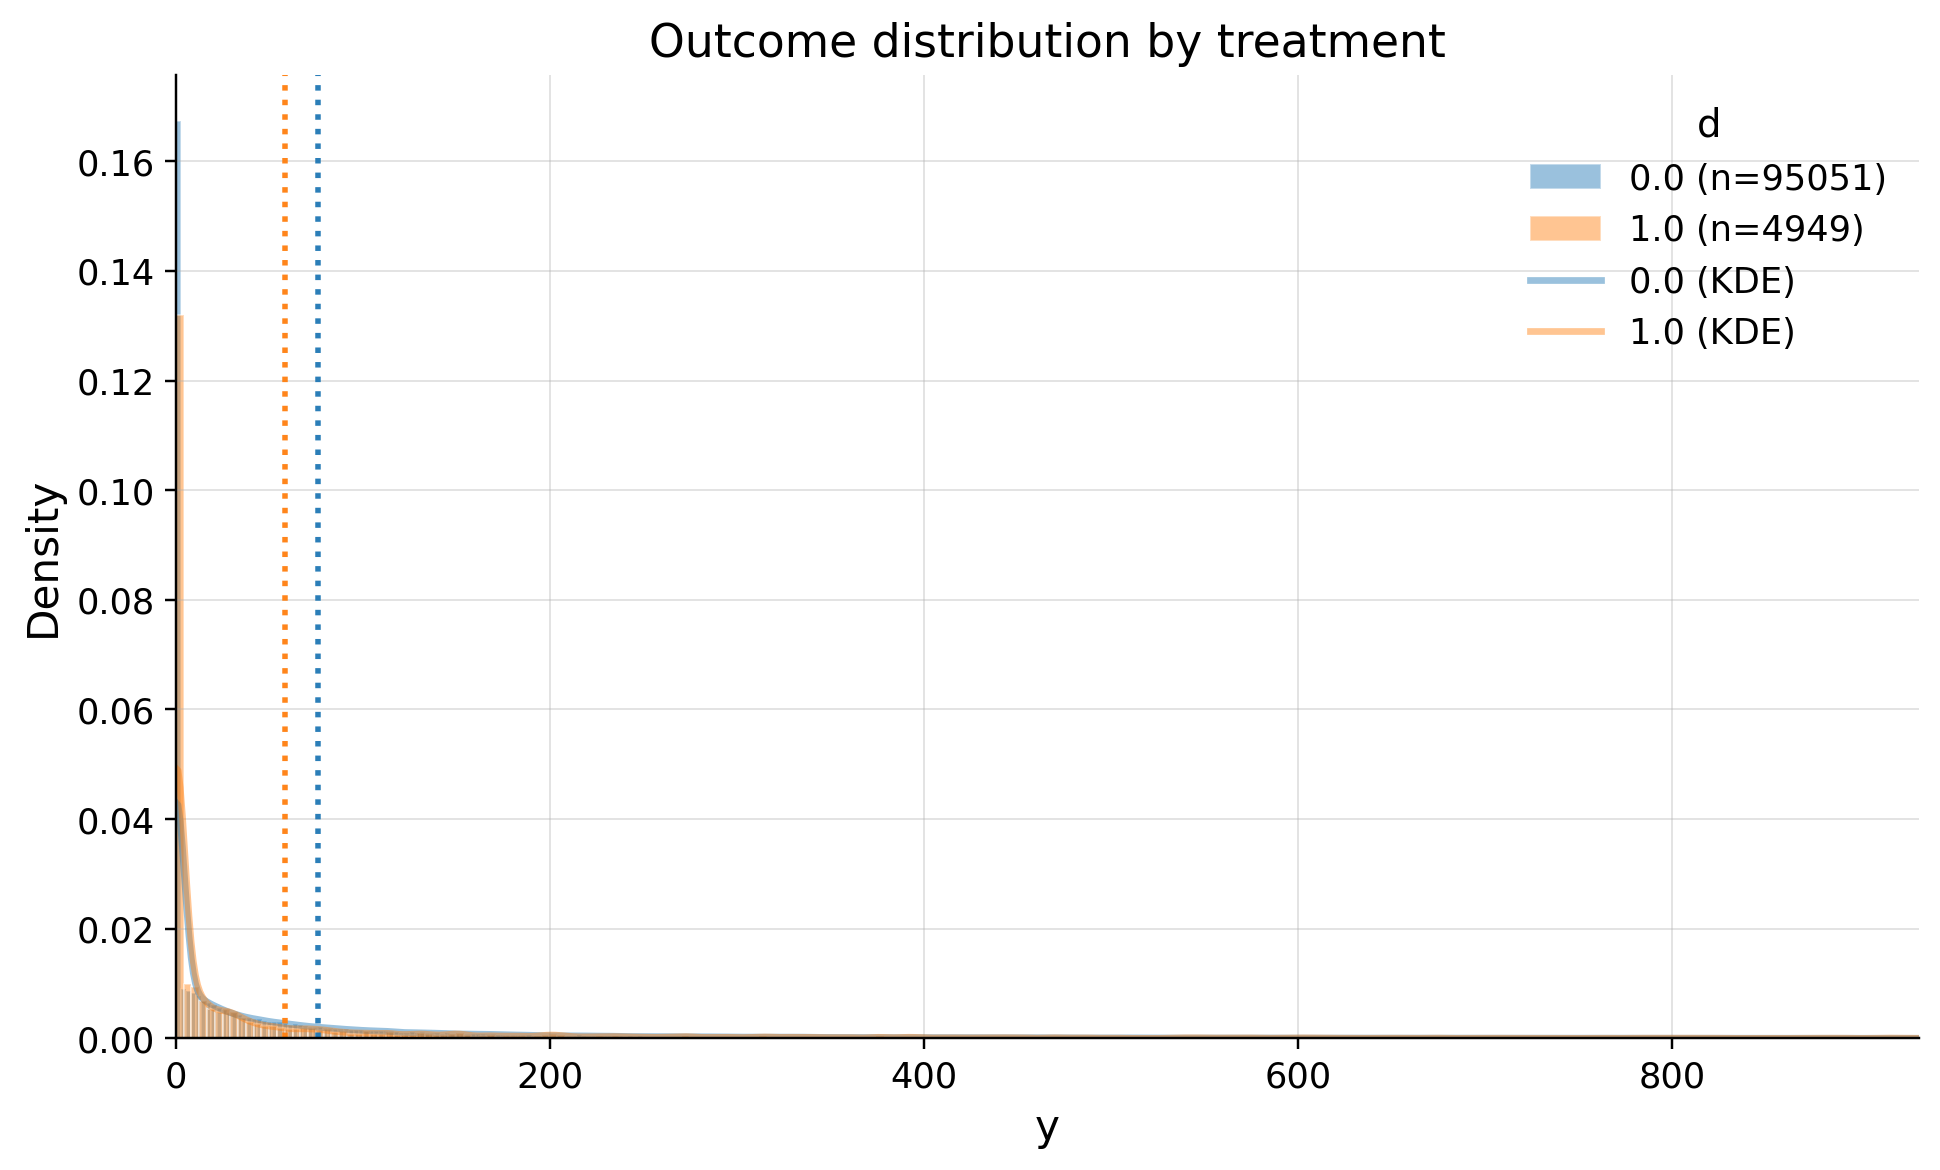

In [5]:
from causalis.shared.outcome_plots import outcome_plot_dist
outcome_plot_dist(causaldata)

We see large right tale

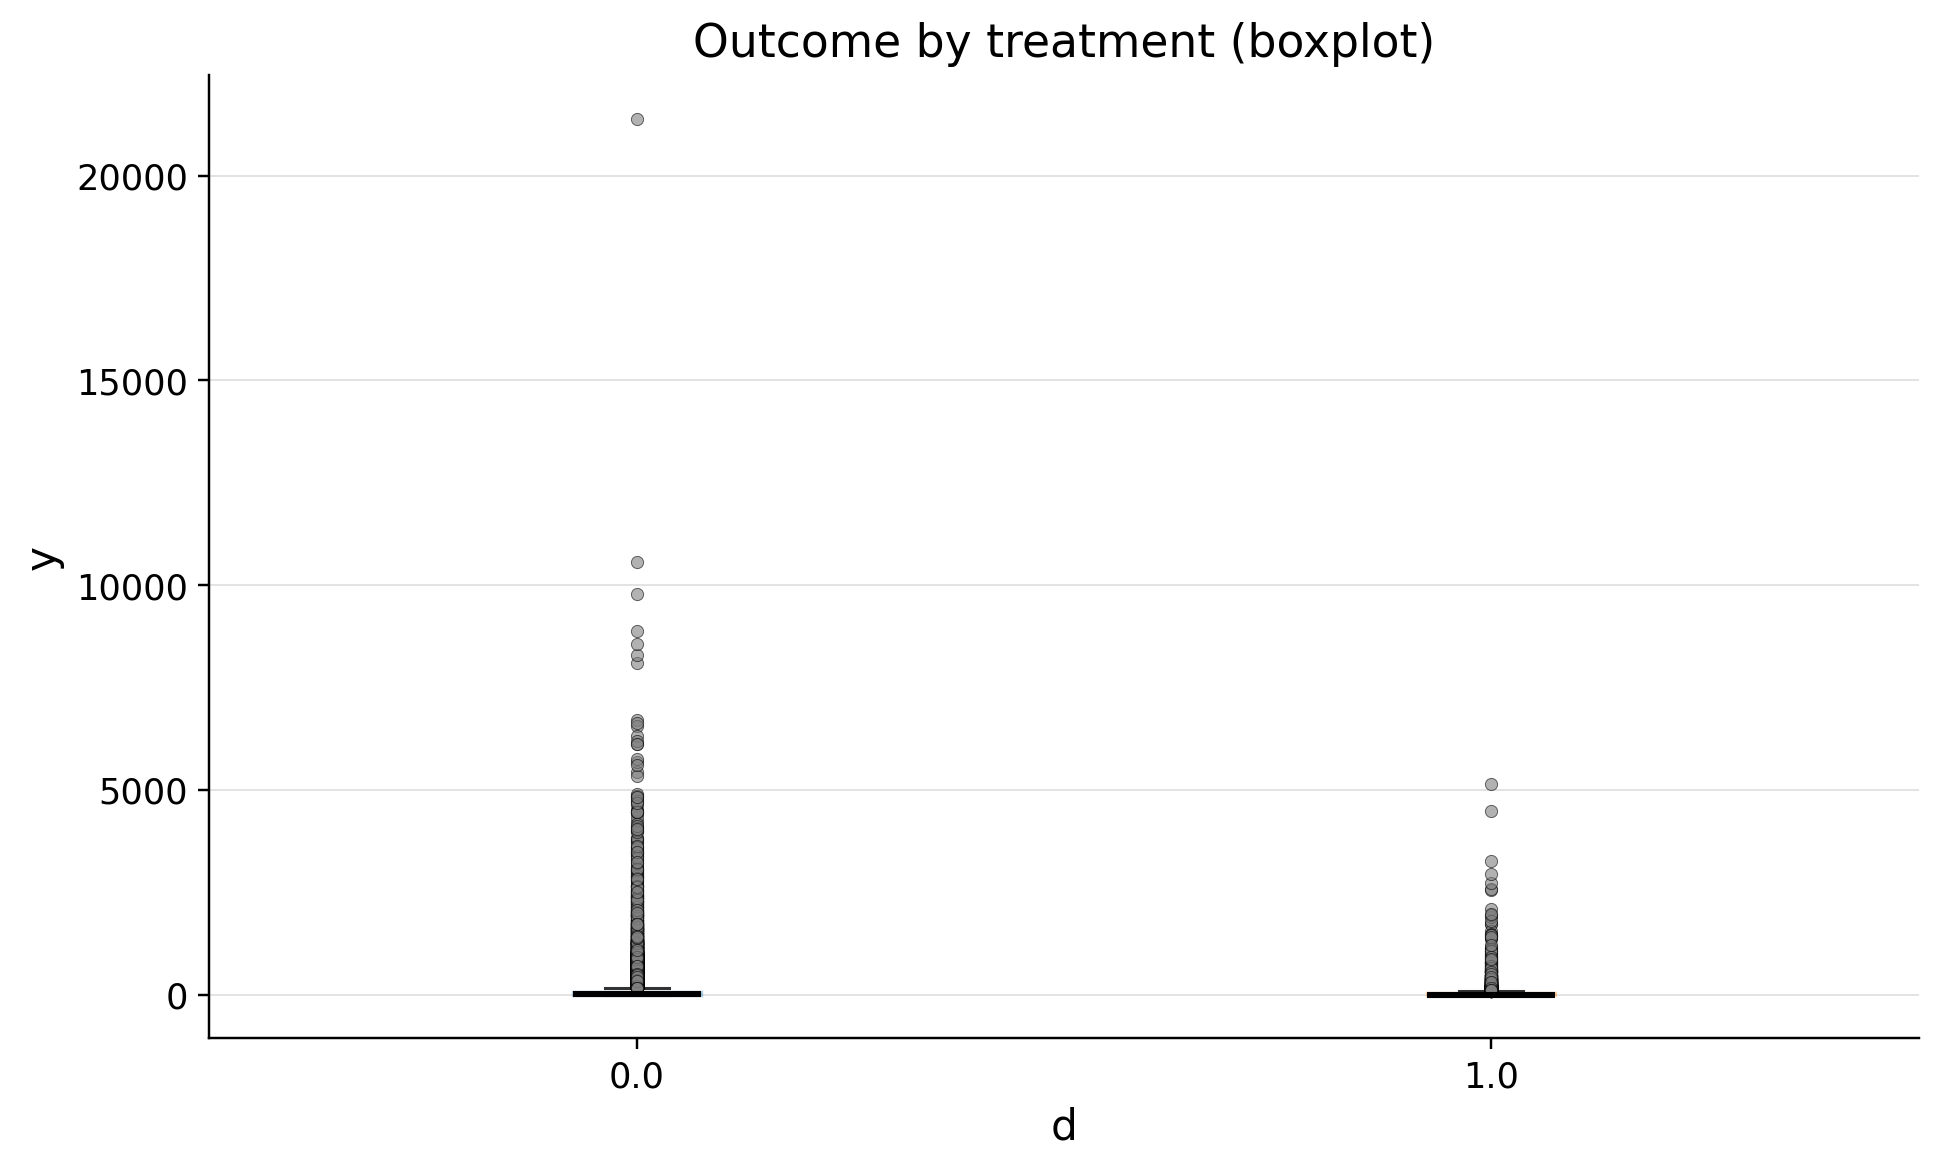

In [6]:
from causalis.shared.outcome_plots import outcome_plot_boxplot
outcome_plot_boxplot(causaldata)

In [7]:
from causalis.shared import outcome_outliers

outcome_outliers(causaldata)

,treatment,n,outlier_count,outlier_rate,lower_bound,upper_bound,has_outliers,method,tail
0,0.0,95051,11300,0.118884,-97.288916,162.148194,True,iqr,both
1,1.0,4949,721,0.145686,-55.437420,92.395699,True,iqr,both


We see many outliers. It's common situation for LTV metric. Dropping them will lead to a biased conclusion

In [8]:
from causalis.shared import confounders_balance

confounders_balance(causaldata)

,confounders,mean_d_0,mean_d_1,abs_diff,smd,ks_pvalue
0,premium_user,0.751807,0.591837,0.159970,-0.345721,0.00000
1,income_monthly,4549.385190,3918.058798,631.326392,-0.277611,0.00000
2,spend_last_month,89.091801,67.375389,21.716412,-0.268360,0.00000
3,support_tickets_90d,0.984545,1.259244,0.274699,0.253974,0.00000
4,avg_sessions_week,5.047753,4.230148,0.817606,-0.201735,0.00000
5,prior_purchases_12m,3.904220,3.513639,0.390581,-0.189372,0.00000
6,tenure_months,28.740100,25.559161,3.180939,-0.184156,0.00000
7,age_years,36.435984,34.809083,1.626901,-0.144142,0.00000
8,referred_user,0.271486,0.307133,0.035647,0.078671,0.00001
9,urban_resident,0.600793,0.568802,0.031991,-0.064954,0.00013


As we see clients are differ on this confounders. We need to controll them to make causal inference

# ATTE

ATTE is right estimand here. We will estimate effect on clients that were treated, had first purchase in our product

In [9]:
from causalis.scenarios.unconfoundedness import IRM

model = IRM(n_jobs=-1).fit(causaldata)

In [10]:
dml_result = model.estimate(score='ATTE')
dml_result.summary()

,value
field,
estimand,ATTE
model,IRM
value,"11.7030 (ci_abs: 7.2449, 16.1611)"
value_relative,"25.0048 (ci_rel: 15.3806, 34.6290)"
alpha,0.0500
p_value,0.0000
is_significant,True
n_treated,4949
n_control,95051


Our estimate is 12.1542 dollars (ci_abs: 7.7933, 16.5152). Mean in treatment group is 58.5062 dollars, so without our product it would be 46.3520 dollars.

## GATET

## Quantile groups GATET

In [11]:
import pandas as pd

groups = pd.qcut(data["prior_purchases_12m"], q=5, duplicates="drop")
result = model.estimate(score="GATET", groups=groups)

result.summary()

,group,value,is_significant,ci_lower,ci_upper,n_group,n_treated,n_control,share_treated,std_error,test_stat,p_value,mean_phi,std_phi,mean_propensity,min_propensity,max_propensity
0,"prior_purchases_12m=(-0.001, 2.0]",5.815230,True,0.588179,11.042281,27484,1700,25784,0.06185,2.666912,2.180511,0.02922,5.815230,442.653459,0.059719,0.01,0.823073
1,"prior_purchases_12m=(2.0, 3.0]",8.376332,False,-1.083934,17.836598,19182,984,18198,0.05130,4.826755,1.735396,0.08267,8.376332,670.049474,0.050492,0.01,0.583411
2,"prior_purchases_12m=(3.0, 4.0]",3.922010,False,-5.991967,13.835987,18236,847,17389,0.04645,5.058245,0.775370,0.43812,3.922010,683.288078,0.045796,0.01,0.519778
3,"prior_purchases_12m=(4.0, 6.0]",21.469848,True,10.726077,32.213618,23812,1014,22798,0.04258,5.481616,3.916700,0.00009,21.469848,851.744757,0.041627,0.01,0.463650
4,"prior_purchases_12m=(6.0, 16.0]",36.380628,True,8.129337,64.631919,11286,404,10882,0.03580,14.414189,2.523946,0.01160,36.380628,1543.213691,0.033757,0.01,0.554571


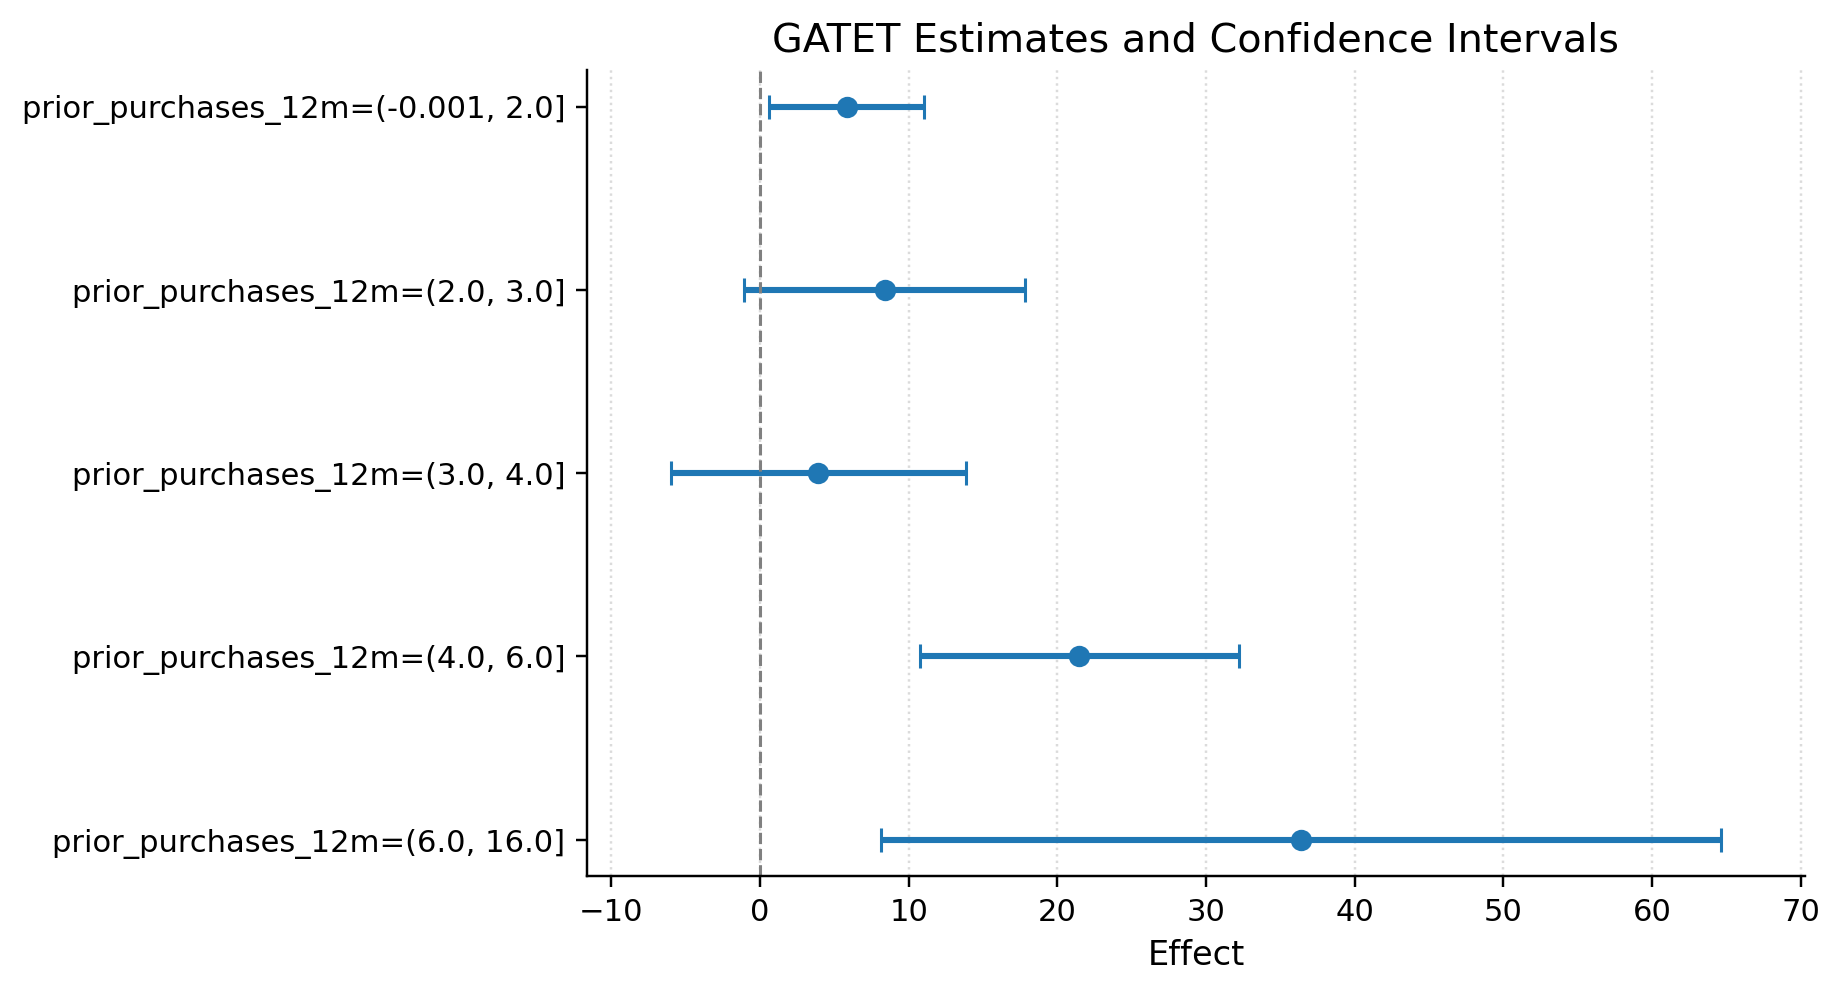

In [12]:
from causalis.scenarios.gate import gate_plot

gate_plot(result)

## Integer groups GATET

In [13]:
result = model.estimate(score='GATET', groups=data['mobile_user'])
result.summary()

,group,value,is_significant,ci_lower,ci_upper,n_group,n_treated,n_control,share_treated,std_error,test_stat,p_value,mean_phi,std_phi,mean_propensity,min_propensity,max_propensity
0,mobile_user=0.0,5.740115,False,-0.723297,12.203527,12565,643,11922,0.05117,3.297720,1.740632,0.08175,5.740115,370.360716,0.048592,0.01,0.823073
1,mobile_user=1.0,12.593462,True,7.562008,17.624917,87435,4306,83129,0.04925,2.567116,4.905686,0.00000,12.593462,761.259047,0.048112,0.01,0.617166


## Formal group comparisons

- `result.summary()` answers which subgroup effects are different from `0`.
- `result.contrast(...)` answers whether one subgroup effect differs from another.
- `result.pairwise_summary(reference=...)` compares every subgroup against a chosen reference group.

In [14]:
result.contrast("mobile_user=1.0", "mobile_user=0.0").summary()

,value
field,
estimand,GATET_CONTRAST
model,IRM
contrast,mobile_user=1.0 - mobile_user=0.0
left_group,mobile_user=1.0
right_group,mobile_user=0.0
value,"6.8533 (ci_abs: -1.3376, 15.0443)"
std_error,4.1791
test_stat,1.6399
alpha,0.0500


In [15]:
result.pairwise_summary(reference="mobile_user=0.0")

,left_group,right_group,contrast_label,left_value,right_value,estimate_diff,std_error,test_stat,p_value,p_value_adj,ci_lower,ci_upper,is_significant,is_significant_adj,n_left,n_right,alpha,p_adjust
0,mobile_user=1.0,mobile_user=0.0,mobile_user=1.0 - mobile_user=0.0,12.593462,5.740115,6.853347,4.179119,1.639902,0.101025,0.101025,-1.337576,15.044271,False,False,87435,12565,0.05,none


## Manual groups GATET

In [16]:
import numpy as np

manual_groups = pd.Series(np.where(causaldata.df["age_years"] < 30, "Young", 
                                   np.where(causaldata.df["age_years"] < 50, "Middle", "Senior")),
                          index=causaldata.df.index)

model.estimate(score="GATET", groups=manual_groups).summary()

,group,value,is_significant,ci_lower,ci_upper,n_group,n_treated,n_control,share_treated,std_error,test_stat,p_value,mean_phi,std_phi,mean_propensity,min_propensity,max_propensity
0,0=Middle,9.255211,True,2.743687,15.766736,57050,2633,54417,0.04615,3.322268,2.785812,0.00534,9.255211,794.703618,0.045350,0.01,0.823073
1,0=Senior,7.901003,False,-9.123459,24.925465,12133,504,11629,0.04154,8.686110,0.909614,0.36303,7.901003,958.003435,0.039543,0.01,0.601238
2,0=Young,16.317476,True,10.295807,22.339144,30817,1812,29005,0.05880,3.072336,5.311097,0.00000,16.317476,543.248095,0.056793,0.01,0.617166


## Multi-column indicator groups GATET

Yes. `groups=` for `score="GATET"` can be a multi-column DataFrame of 0/1 subgroup indicators.

The columns must define a strict partition of the fitted sample:
- every column must be binary,
- every row must belong to exactly one subgroup,
- every subgroup must contain at least one treated observation.

Groups with no controls are still accepted for GATET, but the estimator emits a warning because within-group overlap is degenerate.


In [20]:
age_bucket = pd.cut(
    causaldata.df["age_years"],
    bins=[-np.inf, 30, 50, np.inf],
    labels=["Young", "Middle", "Senior"],
    right=False,
)

segment = age_bucket.astype(str) + "_mobile=" + causaldata.df["mobile_user"].astype(int).astype(str)

groups = pd.get_dummies(segment, dtype=int)
groups.index = causaldata.df["user_id"]

assert (groups.sum(axis=1) == 1).all()

model.estimate(score="GATET", groups=groups).summary()


,group,value,is_significant,ci_lower,ci_upper,n_group,n_treated,n_control,share_treated,std_error,test_stat,p_value,mean_phi,std_phi,mean_propensity,min_propensity,max_propensity
0,Middle_mobile=0,4.351636,False,-4.224174,12.927446,7511,362,7149,0.04820,4.375494,0.994547,0.31996,4.351636,379.777268,0.046450,0.01,0.823073
1,Middle_mobile=1,10.036847,True,2.612594,17.461100,49539,2271,47268,0.04584,3.787954,2.649675,0.00806,10.036847,844.395048,0.045183,0.01,0.604030
2,Senior_mobile=0,5.735265,False,-15.356013,26.826542,2500,113,2387,0.04520,10.761053,0.532965,0.59406,5.735265,537.725806,0.041483,0.01,0.439237
3,Senior_mobile=1,8.526907,False,-12.552376,29.606190,9633,391,9242,0.04059,10.754934,0.792837,0.42787,8.526907,1057.209477,0.039040,0.01,0.601238
4,Young_mobile=0,8.735219,True,0.417677,17.052762,2554,168,2386,0.06578,4.243722,2.058386,0.03955,8.735219,217.072946,0.061850,0.01,0.386215
5,Young_mobile=1,17.092305,True,10.510944,23.673665,28263,1644,26619,0.05817,3.357899,5.090179,0.00000,17.092305,568.645110,0.056336,0.01,0.617166
